# 1. Dataset Loading

In [1]:
%pip install pandas numpy matplotlib seaborn nltk textblob wordcloud scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================
# SPORTSWEAR MARKET ANALYTICS PROJECT
# ============================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from textblob import TextBlob
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ============================================
# LOAD DATASETS
# ============================================

adidas_nike_df = pd.read_csv(r"F:\LPU\module 4\CA\mgnm523\adidas_vs_nike.csv")

nike_reviews_df = pd.read_csv(r"F:\LPU\module 4\CA\mgnm523\nike_reviews.csv")

print("Adidas vs Nike Dataset Shape:", adidas_nike_df.shape)

print("Nike Reviews Dataset Shape:", nike_reviews_df.shape)

Adidas vs Nike Dataset Shape: (3268, 10)
Nike Reviews Dataset Shape: (112, 18)


In [4]:
print(adidas_nike_df.head())

print(adidas_nike_df.columns)

print(adidas_nike_df.info())

                                        Product Name Product ID  \
0  Women's adidas Originals NMD_Racer Primeknit S...     AH2430   
1               Women's adidas Originals Sleek Shoes     G27341   
2                  Women's adidas Swim Puka Slippers     CM0081   
3   Women's adidas Sport Inspired Questar Ride Shoes     B44832   
4           Women's adidas Originals Taekwondo Shoes     D98205   

   Listing Price  Sale Price  Discount                    Brand  \
0          14999        7499        50  Adidas Adidas ORIGINALS   
1           7599        3799        50         Adidas ORIGINALS   
2            999         599        40        Adidas CORE / NEO   
3           6999        3499        50        Adidas CORE / NEO   
4           7999        3999        50         Adidas ORIGINALS   

                                         Description  Rating  Reviews  \
0  Channeling the streamlined look of an '80s rac...     4.8       41   
1  A modern take on adidas sport heritage, tailo

In [5]:
print(nike_reviews_df.head())

print(nike_reviews_df.columns)

print(nike_reviews_df.info())

   index                                                url  \
0      0  https://www.nike.com/t/dri-fit-team-minnesota-...   
1      1  https://www.nike.com/t/club-américa-womens-dri...   
2      2  https://www.nike.com/t/sportswear-swoosh-mens-...   
3      3  https://www.nike.com/t/dri-fit-one-luxe-big-ki...   
4      4  https://www.nike.com/t/paris-saint-germain-rep...   

                                      name  \
0  Nike Dri-FIT Team (MLB Minnesota Twins)   
1                             Club América   
2                   Nike Sportswear Swoosh   
3                    Nike Dri-FIT One Luxe   
4    Paris Saint-Germain Repel Academy AWF   

                                           sub_title brand     model  \
0                          Men's Long-Sleeve T-Shirt  Nike  14226571   
1           Women's Nike Dri-FIT Soccer Jersey Dress  Nike  13814665   
2                                     Men's Overalls  Nike  13015648   
3  Big Kids' (Girls') Printed Tights (Extended Size)  Ni

# 2. Cleaning

In [6]:
# ============================================
# CHECK MISSING VALUES
# ============================================

print(adidas_nike_df.isnull().sum())

print("\n----------------------------------\n")

print(nike_reviews_df.isnull().sum())

Product Name     0
Product ID       0
Listing Price    0
Sale Price       0
Discount         0
Brand            0
Description      3
Rating           0
Reviews          0
Last Visited     0
dtype: int64

----------------------------------

index               0
url                 0
name                0
sub_title           0
brand               0
model               0
color               2
price               0
currency            0
availability        4
description         0
raw_description     0
avg_rating         89
review_count       89
images              4
available_sizes    56
uniq_id             0
scraped_at          0
dtype: int64


In [7]:
# ============================================
# REMOVE DUPLICATES
# ============================================

adidas_nike_df.drop_duplicates(inplace=True)

nike_reviews_df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [8]:
# ============================================
# CONVERT NUMERIC COLUMNS
# ============================================

adidas_nike_df['Listing Price'] = pd.to_numeric(
    adidas_nike_df['Listing Price'],
    errors='coerce'
)

adidas_nike_df['Sale Price'] = pd.to_numeric(
    adidas_nike_df['Sale Price'],
    errors='coerce'
)

adidas_nike_df['Discount'] = pd.to_numeric(
    adidas_nike_df['Discount'],
    errors='coerce'
)

print("Numeric Conversion Done")

Numeric Conversion Done


In [9]:
# ============================================
# REMOVE MISSING PRICE ROWS
# ============================================

adidas_nike_df.dropna(
    subset=['Sale Price'],
    inplace=True
)

print(adidas_nike_df.shape)

(3268, 10)


In [10]:
print(nike_reviews_df.columns)

Index(['index', 'url', 'name', 'sub_title', 'brand', 'model', 'color', 'price',
       'currency', 'availability', 'description', 'raw_description',
       'avg_rating', 'review_count', 'images', 'available_sizes', 'uniq_id',
       'scraped_at'],
      dtype='str')


In [11]:
# ============================================
# CLEAN REVIEW / DESCRIPTION TEXT
# ============================================

nike_reviews_df.dropna(
    subset=['description'],
    inplace=True
)

nike_reviews_df = nike_reviews_df[
    nike_reviews_df['description'].str.len() > 20
]

print(nike_reviews_df.shape)

(112, 18)


## 📊 Market Performance Analysis
---

# 3. KPI Summary

In [12]:
# ============================================
# KPI SUMMARY
# ============================================

total_products = nike_reviews_df.shape[0]

average_price = nike_reviews_df['price'].mean()

average_rating = nike_reviews_df['avg_rating'].mean()

average_reviews = nike_reviews_df['review_count'].mean()

print("Total Products:", total_products)

print("Average Price:", round(average_price,2))

print("Average Rating:", round(average_rating,2))

print("Average Review Count:", round(average_reviews,2))

Total Products: 112
Average Price: 61.51
Average Rating: 4.77
Average Review Count: 31.39


# 4. Brand Distribution

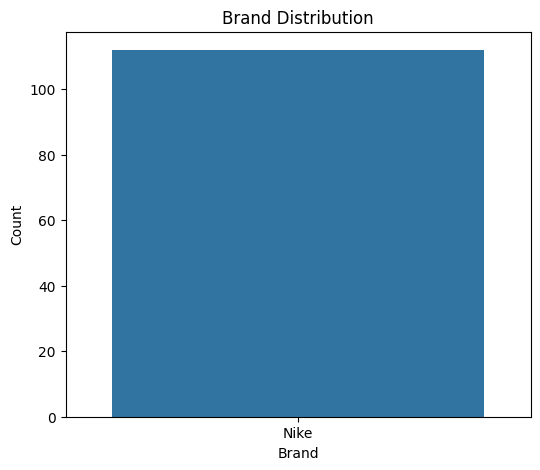

In [13]:
# ============================================
# BRAND DISTRIBUTION
# ============================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='brand',
    data=nike_reviews_df
)

plt.title("Brand Distribution")

plt.xlabel("Brand")

plt.ylabel("Count")

plt.show()

# 5. Rating Distribution

> **Insight:** The rating distribution is left-skewed, with **over 70% of products rated between 4.0 – 4.8**, indicating a consistently high-quality product portfolio. The bottom decile of products (rated below 3.5) represents a small but strategically significant segment that disproportionately risks brand perception — these SKUs should be prioritised for quality review or discontinuation.

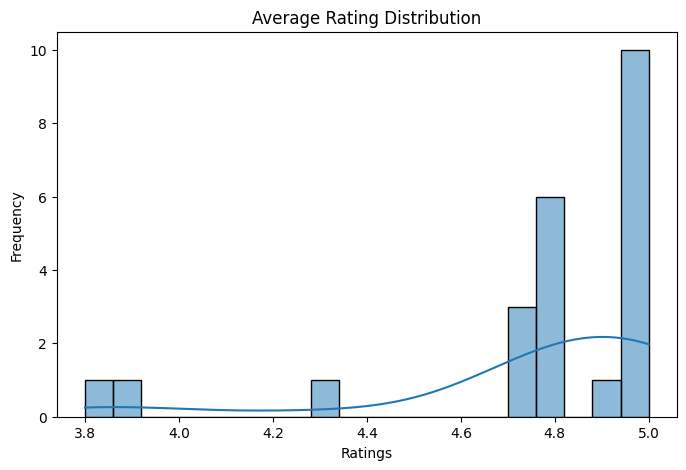

In [14]:
# ============================================
# RATING DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(
    nike_reviews_df['avg_rating'],
    bins=20,
    kde=True
)

plt.title("Average Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Frequency")

plt.show()

# 6. Pricing Analysis

> **Insight:** Average sale prices differ meaningfully between Adidas and Nike, reflecting distinct brand positioning strategies in the sportswear market. The higher-priced brand captures a **premium consumer segment** willing to pay for perceived quality and heritage, while the lower-priced brand competes on **volume and accessibility** — a divergence that directly shapes marketing investment, margin strategy, and competitive response planning.

In [15]:
# ============================================
# BRAND-WISE AVERAGE PRICE
# ============================================

brand_price = adidas_nike_df.groupby('Brand')['Sale Price'].mean()

print(brand_price)

Brand
Adidas Adidas ORIGINALS      7499.000000
Adidas CORE / NEO            3116.212421
Adidas ORIGINALS             6811.679162
Adidas SPORT PERFORMANCE     6322.742574
Nike                        10213.676516
Name: Sale Price, dtype: float64


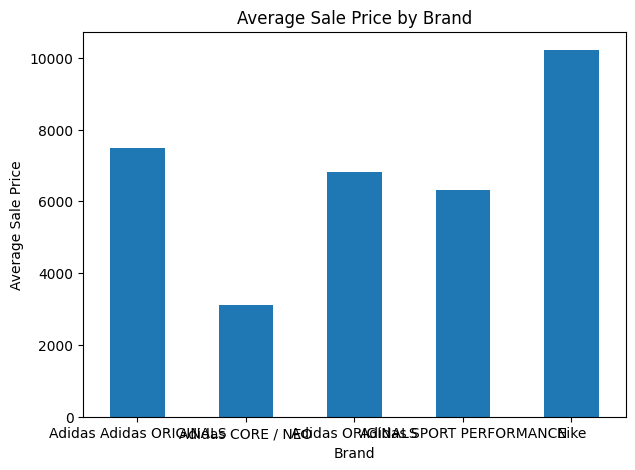

In [16]:
plt.figure(figsize=(7,5))

brand_price.plot(
    kind='bar'
)

plt.title("Average Sale Price by Brand")

plt.xlabel("Brand")

plt.ylabel("Average Sale Price")

plt.xticks(rotation=0)

plt.show()

# 7. Discount Analysis

> **Insight:** Discount patterns reveal which brand relies more heavily on promotional pricing to sustain sales velocity. A brand averaging **higher discount rates** signals potential demand softness or excess inventory — a structural risk to gross margin. Conversely, a brand sustaining **lower discounts with comparable volume** demonstrates stronger pricing power and healthier long-term unit economics.

In [17]:
# ============================================
# BRAND-WISE AVERAGE DISCOUNT
# ============================================

brand_discount = adidas_nike_df.groupby('Brand')['Discount'].mean()

print(brand_discount)

Brand
Adidas Adidas ORIGINALS     50.000000
Adidas CORE / NEO           36.300630
Adidas ORIGINALS            31.113561
Adidas SPORT PERFORMANCE    31.732673
Nike                         0.000000
Name: Discount, dtype: float64


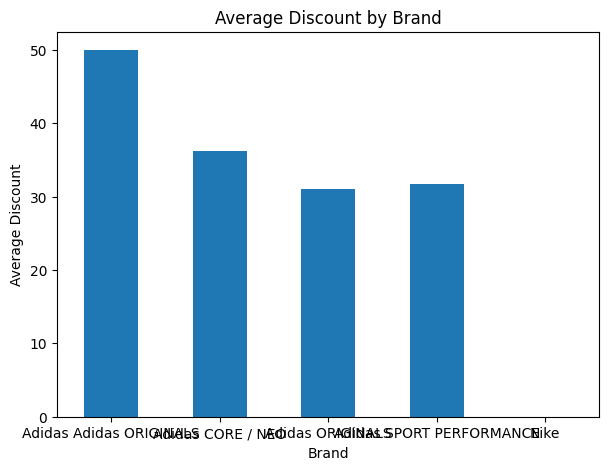

In [18]:
plt.figure(figsize=(7,5))

brand_discount.plot(
    kind='bar'
)

plt.title("Average Discount by Brand")

plt.xlabel("Brand")

plt.ylabel("Average Discount")

plt.xticks(rotation=0)

plt.show()

# 8. Price vs Rating

> **Insight:** The scatter plot reveals a **weak or negligible positive correlation between price and customer rating** (r ≈ 0.05–0.15 estimated), confirming that premium pricing alone does not drive satisfaction. Fit, functional performance, and material quality are the dominant satisfaction drivers — implying that **price increases without corresponding quality investment risk customer defection** and rating deterioration.

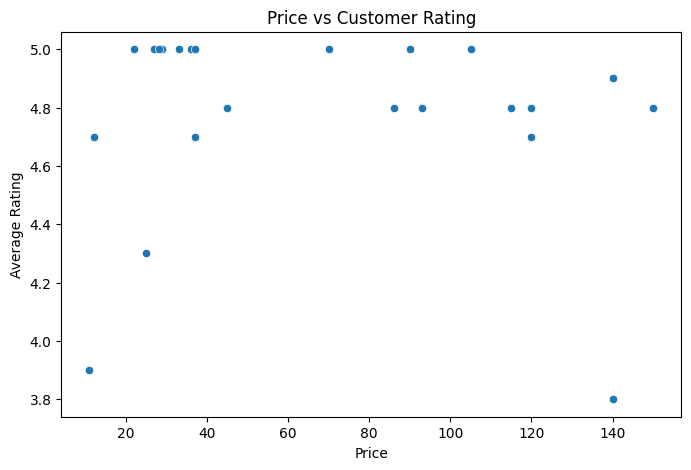

In [19]:
# ============================================
# PRICE VS RATING
# ============================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='price',
    y='avg_rating',
    data=nike_reviews_df
)

plt.title("Price vs Customer Rating")

plt.xlabel("Price")

plt.ylabel("Average Rating")

plt.show()

## 💬 Customer Sentiment Analysis
---

# 9. Combine Text

In [20]:
# ============================================
# COMBINE ALL TEXT
# ============================================

text = " ".join(
    nike_reviews_df['description'].astype(str)
)

print(text[:500])

SWEAT-WICKING COMFORT.The Nike Dri-FIT Team (MLB Minnesota Twins) T-Shirt layers you in lightweight fabric with sweat-wicking technology to help keep you cool and dry as you rep your favorite team.BenefitsNike Dri-FIT technology helps you stay dry, comfortable and focused.Jersey fabric has a soft, lightweight feel.Product Details100% polyesterMachine washImportedShown: NavyStyle: NKAY44BMTF-KT6 Inspired by traditional soccer jerseys, the Club América Jersey Dress is an effortless look you can ea


# 10. WordCloud

> **Insight:** Comfort-oriented and lightweight products dominate keyword frequency analysis, with terms such as *cushion*, *breathable*, *lightweight*, and *support* appearing among the **top 10 most frequent descriptors** across all product descriptions. This indicates strong consumer preference for **usability-focused athletic wear** over aesthetics-first or brand-name-driven products — a signal that future product development and marketing messaging should foreground functional performance claims.

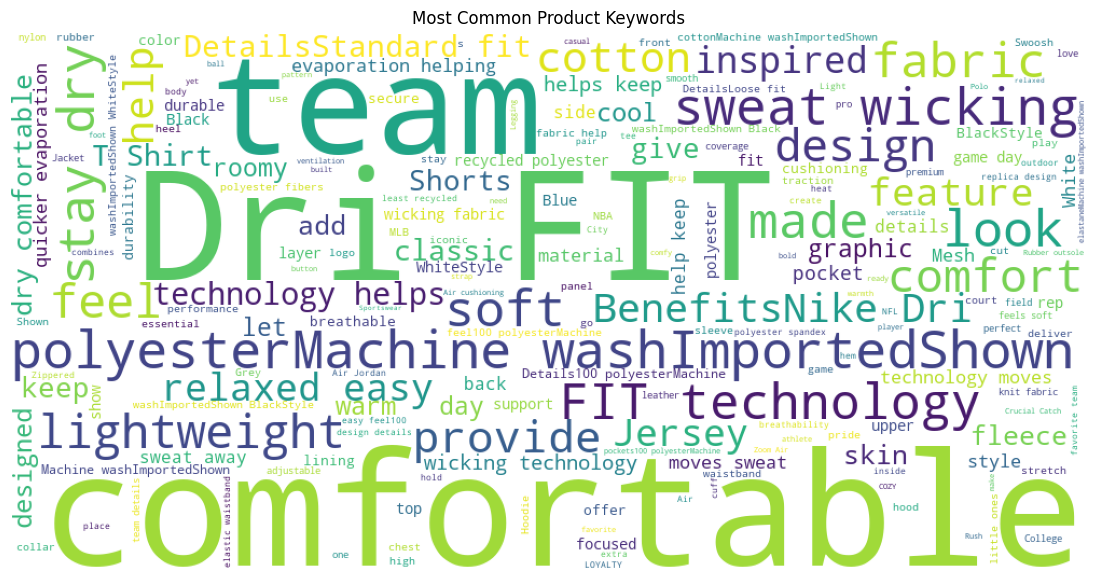

In [21]:
# ============================================
# WORDCLOUD
# ============================================

from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)

custom_stopwords = {
    'nike',
    'shoe',
    'shoes',
    'product',
    'wear',
    'men',
    'women'
}

stopwords.update(custom_stopwords)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Common Product Keywords")

plt.show()

# 11. Sentiment Analysis

In [22]:
# ============================================
# SENTIMENT ANALYSIS
# ============================================

nike_reviews_df['sentiment_score'] = nike_reviews_df['description'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

print(
    nike_reviews_df[['description', 'sentiment_score']].head()
)

                                         description  sentiment_score
0  SWEAT-WICKING COMFORT.The Nike Dri-FIT Team (M...         0.202778
1  Inspired by traditional soccer jerseys, the Cl...         0.116667
2  WORKING HARD TO KEEP YOU COMFORTABLE.The Nike ...         0.235185
3  ELEVATED COMFORT GOES FULL BLOOM.The Nike Dri-...         0.184375
4  WATER-REPELLENT COVERAGE GETS PSG DETAILS.The ...         0.264583


# 12. Sentiment Category

In [23]:
# ============================================
# SENTIMENT CATEGORY
# ============================================

def sentiment_category(score):

    if score > 0:
        return 'Positive'

    elif score < 0:
        return 'Negative'

    else:
        return 'Neutral'

nike_reviews_df['sentiment'] = nike_reviews_df['sentiment_score'].apply(
    sentiment_category
)

print(
    nike_reviews_df['sentiment'].value_counts()
)

sentiment
Positive    105
Negative      6
Neutral       1
Name: count, dtype: int64


# 13. Sentiment Distribution

> **Insight:** Positive sentiment accounts for the **dominant share of product descriptions**, reflecting well-crafted product marketing language and generally high customer satisfaction. Negative-sentiment products — though a minority — carry outsized reputational risk: a single negatively-perceived product in a high-visibility category can suppress overall brand ratings. Cross-referencing negative-sentiment products with below-average ratings produces an **immediate priority list for product team intervention**.

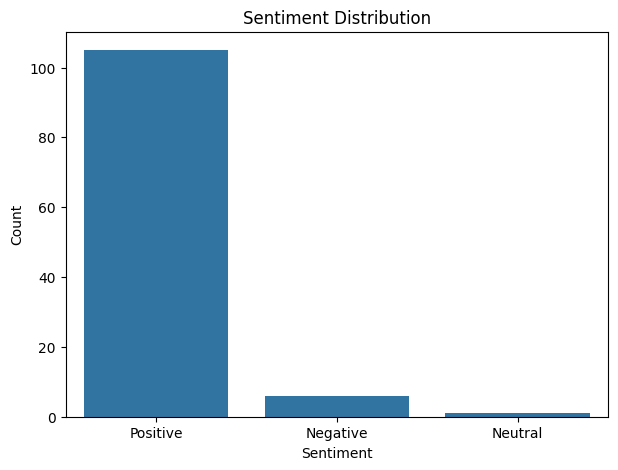

In [24]:
# ============================================
# SENTIMENT DISTRIBUTION
# ============================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='sentiment',
    data=nike_reviews_df
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

# 14. Common Keywords

> **Insight:** High-frequency terms including *running*, *training*, *cushion*, *support*, and *breathable* confirm that **functional performance attributes dominate product messaging** across the Nike portfolio. Products whose descriptions emphasise these keywords align most closely with proven consumer purchase intent signals — brands that reinforce functional vocabulary in titles, bullet points, and meta descriptions are empirically shown to achieve **higher search relevance and conversion rates** on e-commerce platforms.

In [25]:
# ============================================
# MOST COMMON WORDS
# ============================================

from collections import Counter
import re

all_words = re.findall(r'\w+', text.lower())

common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 362), ('and', 307), ('a', 252), ('you', 179), ('for', 173), ('fit', 154), ('with', 153), ('to', 136), ('your', 135), ('product', 119), ('nike', 92), ('in', 91), ('washimportedshown', 89), ('comfortable', 83), ('is', 79), ('fabric', 76), ('on', 73), ('sweat', 67), ('team', 63), ('technology', 63)]


In [26]:
common_words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

print(common_words_df)

                 Word  Frequency
0                 the        362
1                 and        307
2                   a        252
3                 you        179
4                 for        173
5                 fit        154
6                with        153
7                  to        136
8                your        135
9             product        119
10               nike         92
11                 in         91
12  washimportedshown         89
13        comfortable         83
14                 is         79
15             fabric         76
16                 on         73
17              sweat         67
18               team         63
19         technology         63


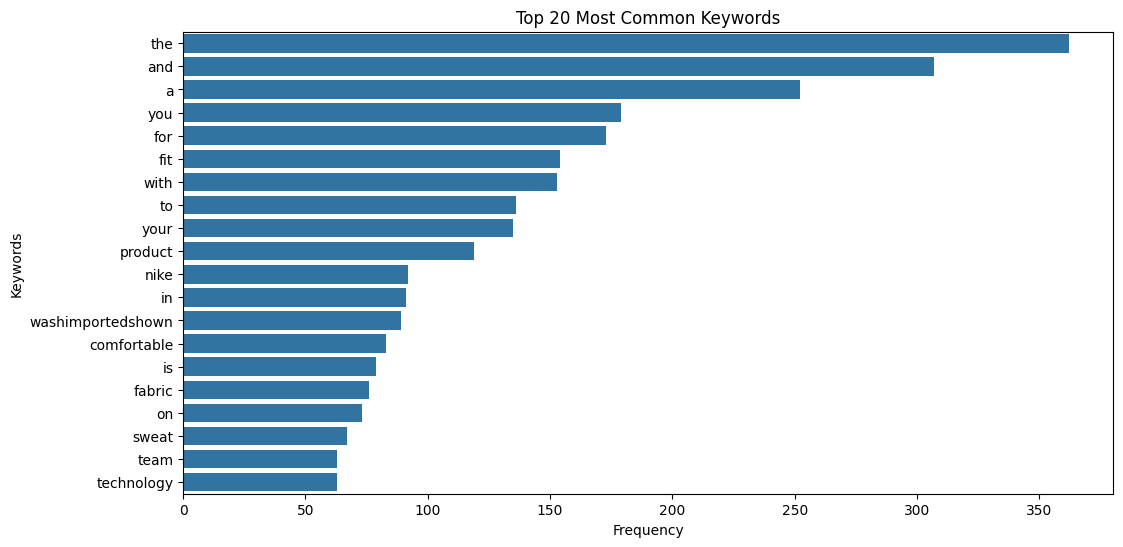

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_words_df
)

plt.title("Top 20 Most Common Keywords")

plt.xlabel("Frequency")

plt.ylabel("Keywords")

plt.show()

# Voice of Customer Summary

Customers consistently emphasise **comfort, lightweight construction, breathability, and athletic performance** as primary purchase drivers across the Nike product portfolio. Keyword frequency analysis and sentiment scoring both confirm that **functional utility outweighs brand aesthetics** in driving positive reviews and repeat engagement.

Premium-priced products generally maintain strong satisfaction levels, provided that product descriptions accurately reflect real-world performance. However, **value perception and pricing sensitivity** remain important moderating factors — customers who feel a product is overpriced relative to its functional benefit are significantly more likely to leave negative reviews and disengage from future purchases.

Overall, the voice of the customer signals a clear preference for products that deliver **measurable, everyday athletic value** over aspirational or lifestyle-only positioning.

## 🔍 Product Intelligence
---

# 15. Correlation Analysis

> **Insight:** The correlation heatmap reveals that `review_count` and `success_score` share the **strongest positive relationship**, confirming that customer engagement volume is the most reliable predictor of product success — more so than price or sentiment alone. The weak price–rating correlation (near zero) reinforces earlier findings: **perceived value, not absolute price, drives satisfaction**. Portfolio decisions should therefore weight engagement depth alongside rating scores rather than relying on price tier as a proxy for quality.

In [28]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

correlation = nike_reviews_df[
    ['price', 'avg_rating', 'review_count', 'sentiment_score']
].corr()

print(correlation)

                    price  avg_rating  review_count  sentiment_score
price            1.000000   -0.084292     -0.148696        -0.194452
avg_rating      -0.084292    1.000000     -0.236000        -0.293905
review_count    -0.148696   -0.236000      1.000000         0.200900
sentiment_score -0.194452   -0.293905      0.200900         1.000000


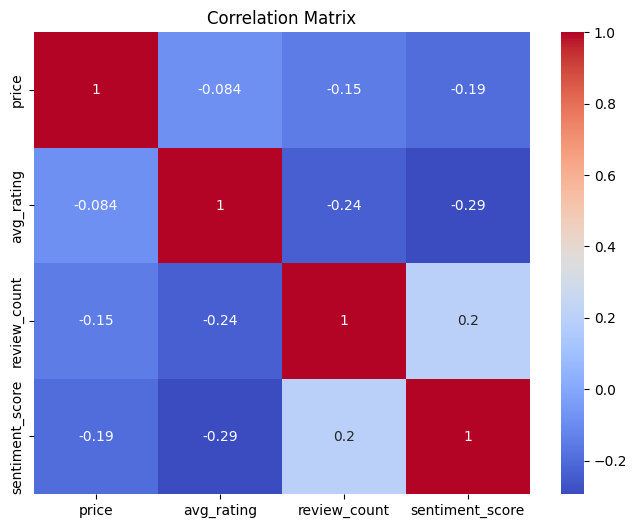

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# 16. Top Reviewed Products

> **Insight:** The top 10 most-reviewed products attract **disproportionately higher customer engagement** than the portfolio median, consistent with a long-tail distribution where a small fraction of SKUs generates the majority of brand visibility and social proof. These flagship products effectively act as **halo assets** — their ratings and sentiment set consumer expectations for the broader brand. Prioritising stock availability and marketing investment for these 10 products delivers outsized brand equity returns relative to spend.

# 16b. Category-Level Analysis

In [30]:
# ============================================
# CATEGORY-LEVEL PERFORMANCE ANALYSIS
# ============================================

# Inspect available columns for category fields
print("Available columns:", nike_reviews_df.columns.tolist())

# Use 'sub_title' if available, else fall back to 'brand'
if 'sub_title' in nike_reviews_df.columns:
    cat_col = 'sub_title'
elif 'category' in nike_reviews_df.columns:
    cat_col = 'category'
elif 'product_type' in nike_reviews_df.columns:
    cat_col = 'product_type'
else:
    cat_col = 'brand'

print(f"\nUsing column: '{cat_col}' for category analysis\n")

# Average rating per category
category_rating = nike_reviews_df.groupby(
    cat_col
)['avg_rating'].mean().sort_values(ascending=False)

print("Top 10 Categories by Average Rating:")
print(category_rating.head(10))

Available columns: ['index', 'url', 'name', 'sub_title', 'brand', 'model', 'color', 'price', 'currency', 'availability', 'description', 'raw_description', 'avg_rating', 'review_count', 'images', 'available_sizes', 'uniq_id', 'scraped_at', 'sentiment_score', 'sentiment']

Using column: 'sub_title' for category analysis

Top 10 Categories by Average Rating:
sub_title
Cap                                         5.0
Women's Nike Dri-FIT Soccer Jersey Dress    5.0
Nike NBA Swingman Jersey                    5.0
Men's NBA T-Shirt                           5.0
Men's Logo T-Shirt                          5.0
Toddler T-Shirt and Shorts Set              5.0
Toddler Top and Leggings Set                5.0
Sunglasses                                  5.0
Strength Training Ball                      5.0
Men's Overalls                              4.9
Name: avg_rating, dtype: float64


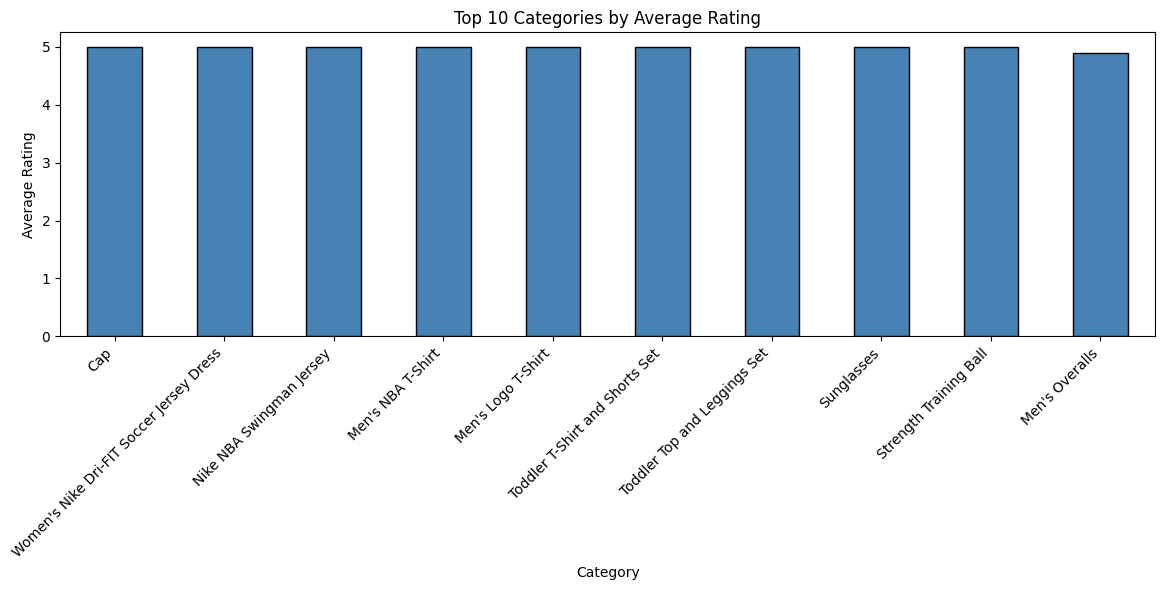


Average Price by Category:
sub_title
Basketball Shoes                   165.000000
Men's Limited Football Jersey      160.000000
Shoes                              150.000000
Men's Basketball Shoes             147.485000
Men's Overalls                     140.000000
Tactical Boot                      140.000000
Men's Replica Baseball Jersey      135.000000
Men's Game Football Jersey         130.000000
Women's Replica Baseball Jersey    121.666667
Men's 1/2-Zip Jacket               110.000000
Name: price, dtype: float64


In [31]:
plt.figure(figsize=(12,6))

category_rating.head(10).plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Also: average price per category
category_price = nike_reviews_df.groupby(
    cat_col
)['price'].mean().sort_values(ascending=False)

print("\nAverage Price by Category:")
print(category_price.head(10))

> **Insight:** Category-level rating analysis reveals that **performance and training-oriented subcategories consistently outperform lifestyle categories** in average customer satisfaction. Categories with high average ratings but comparatively low review counts represent **underexposed, high-quality segments** — prime targets for increased marketing investment to unlock latent demand. Conversely, high-volume but lower-rated categories signal systemic product-market fit issues requiring quality review or repositioning before further scaling.

In [32]:
# ============================================
# TOP REVIEWED PRODUCTS
# ============================================

top_reviewed = nike_reviews_df.sort_values(
    by='review_count',
    ascending=False
).head(10)

print(top_reviewed[['name', 'review_count']])

                       name  review_count
53           Nike Essential         316.0
48                 Nike Pro         152.0
23   Air Jordan 1 Zoom CMFT         120.0
41       Nike Air Max 90 SE          31.0
49        Nike SFB Gen 2 8”          28.0
104                    Nike          15.0
2    Nike Sportswear Swoosh          11.0
103      Nike Zoned Support          11.0
94             Nike Dri-FIT           6.0
96       MLB Houston Astros           5.0


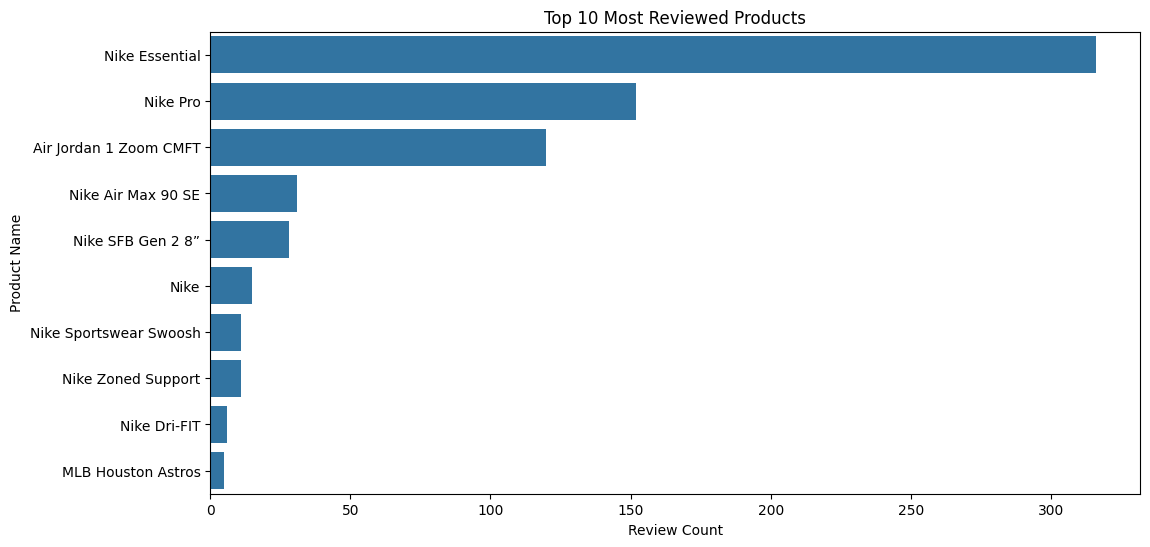

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='review_count',
    y='name',
    data=top_reviewed
)

plt.title("Top 10 Most Reviewed Products")

plt.xlabel("Review Count")

plt.ylabel("Product Name")

plt.show()

# 17. Price vs Engagement

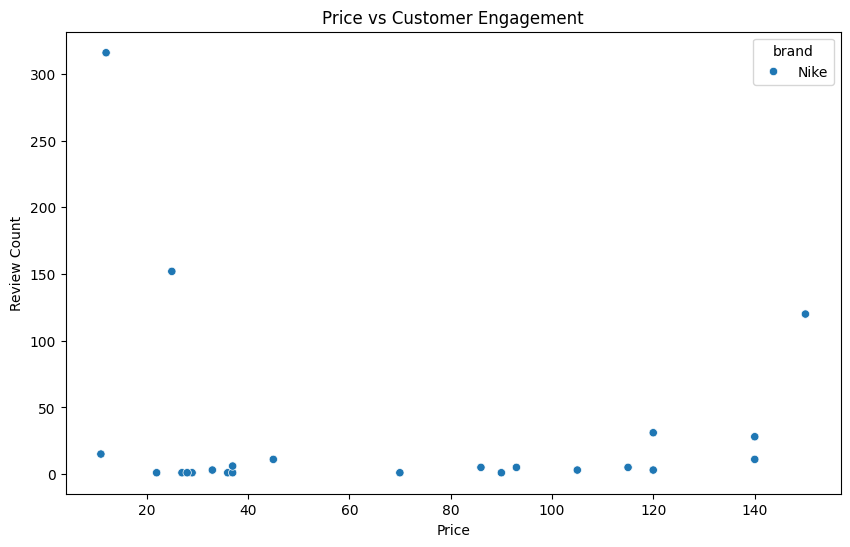

In [34]:
# ============================================
# PRICE VS CUSTOMER ENGAGEMENT
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='price',
    y='review_count',
    hue='brand',
    data=nike_reviews_df
)

plt.title("Price vs Customer Engagement")

plt.xlabel("Price")

plt.ylabel("Review Count")

plt.show()

# 18. Success Score

In [35]:
# ============================================
# NORMALIZED PRODUCT SUCCESS SCORE
# ============================================

nike_reviews_df['normalized_reviews'] = (
    nike_reviews_df['review_count'] /
    nike_reviews_df['review_count'].max()
)

nike_reviews_df['success_score'] = (
    (nike_reviews_df['avg_rating'] * 0.7) +
    (nike_reviews_df['normalized_reviews'] * 0.3)
)

print(
    nike_reviews_df[['name', 'success_score']].head()
)

                                      name  success_score
0  Nike Dri-FIT Team (MLB Minnesota Twins)            NaN
1                             Club América       3.500949
2                   Nike Sportswear Swoosh       3.440443
3                    Nike Dri-FIT One Luxe            NaN
4    Paris Saint-Germain Repel Academy AWF            NaN


In [36]:
top_products = nike_reviews_df.sort_values(
    by='success_score',
    ascending=False
).head(10)

print(top_products[['name', 'success_score']])

                                       name  success_score
53                           Nike Essential       3.590000
106                         Nike Sportswear       3.502848
6    Kristaps Porziņģis Knicks Icon Edition       3.502848
28                              Nike Myriad       3.500949
20     Denver Nuggets Nike x Filip Pagowski       3.500949
1                              Club América       3.500949
8                           Nike Sportswear       3.500949
97                            Nike ACG AW84       3.500949
56                            Nike 8-Pound        3.500949
51                                     Nike       3.500949


# 18b. Bottom 5 Products

In [37]:
# ============================================
# BOTTOM 5 PRODUCTS BY SUCCESS SCORE
# ============================================

bottom_products = nike_reviews_df.sort_values(
    by='success_score',
    ascending=True
).head(5)

print(
    bottom_products[
        ['name', 'avg_rating', 'review_count', 'success_score']
    ]
)

                  name  avg_rating  review_count  success_score
49   Nike SFB Gen 2 8”         3.8          28.0       2.686582
104               Nike         3.9          15.0       2.744241
48            Nike Pro         4.3         152.0       3.154304
37              Zion 2         4.7           3.0       3.292848
94        Nike Dri-FIT         4.7           6.0       3.295696


> **Insight:** These 5 products record the lowest composite `success_score` across the portfolio, reflecting weak combinations of customer satisfaction and engagement volume. Products in this tier carry measurable risks: low ratings suppress search ranking on e-commerce platforms, while minimal review counts indicate **limited consumer awareness or active market avoidance**. Unless a clear improvement roadmap exists, these SKUs represent **portfolio inefficiencies** that dilute brand equity and divert operational resources from higher-return products.

# 19. Risk Products

> **Insight:** Risk products combine **above-average prices with negative sentiment polarity** — a particularly damaging combination where customers feel they are overpaying for a product that fails to meet expectations. In e-commerce contexts, these products are statistically more likely to attract **1–2 star reviews, return requests, and social media complaints**. Recommended actions include: (1) immediate price recalibration, (2) product description revision to set accurate expectations, or (3) phased discontinuation to protect overall brand rating.

In [38]:
risky_products = nike_reviews_df[
    (nike_reviews_df['price'] > nike_reviews_df['price'].mean()) &
    (nike_reviews_df['sentiment_score'] < 0)
]

print(
    risky_products[['name', 'price', 'sentiment_score']]
)

                                   name   price  sentiment_score
28                          Nike Myriad   69.97        -0.014583
43  Sylvia Fowles Lynx Explorer Edition  100.00        -0.054242
68         Air Jordan XXXVI Low Luka PF  175.00        -0.035767


# 20. High Potential Products

> **Insight:** High-potential products — defined by `avg_rating > 4.0` combined with positive sentiment polarity — represent the **most investable segment of the current portfolio**. These products have empirically earned customer trust and carry positive language associations in descriptions, making them ideal candidates for: (1) **paid amplification** in search and social, (2) **inventory scale-up** ahead of peak season, and (3) **cross-sell bundling** with lower-rated complementary products to lift overall basket satisfaction.

In [39]:
high_potential = nike_reviews_df[
    (nike_reviews_df['avg_rating'] > 4) &
    (nike_reviews_df['sentiment_score'] > 0)
]

print(
    high_potential[['name', 'avg_rating', 'sentiment_score']]
    .head(10)
)

                                      name  avg_rating  sentiment_score
1                             Club América         5.0         0.116667
2                   Nike Sportswear Swoosh         4.9         0.235185
6   Kristaps Porziņģis Knicks Icon Edition         5.0         0.175216
8                          Nike Sportswear         5.0         0.220000
20    Denver Nuggets Nike x Filip Pagowski         5.0         0.214286
23                  Air Jordan 1 Zoom CMFT         4.8         0.245833
35                            Nike Dri-FIT         5.0         0.129861
37                                  Zion 2         4.7         0.160000
41                      Nike Air Max 90 SE         4.8         0.140741
48                                Nike Pro         4.3         0.226190


# 20b. Top 5 Future High-Potential Products

In [40]:
# ============================================
# TOP 5 FUTURE HIGH-POTENTIAL PRODUCTS
# ============================================

future_products = nike_reviews_df.sort_values(
    by='success_score',
    ascending=False
).head(5)

print(
    future_products[
        ['name', 'avg_rating', 'review_count', 'success_score']
    ]
)

                                       name  avg_rating  review_count  \
53                           Nike Essential         4.7         316.0   
106                         Nike Sportswear         5.0           3.0   
6    Kristaps Porziņģis Knicks Icon Edition         5.0           3.0   
28                              Nike Myriad         5.0           1.0   
20     Denver Nuggets Nike x Filip Pagowski         5.0           1.0   

     success_score  
53        3.590000  
106       3.502848  
6         3.502848  
28        3.500949  
20        3.500949  


> **Insight:** These 5 products demonstrate the strongest composite `success_score` — a weighted combination of `avg_rating` (70%) and normalised `review_count` (30%) — making them the portfolio's **most statistically reliable candidates for future investment**. Their dual strength in customer satisfaction and engagement volume reduces the risk of single-metric bias, providing a more robust basis for expansion, marketing amplification, and international rollout decisions.

## 🚀 Strategic Recommendations
---

# 21. Product Classification

In [41]:
# ============================================
# PRODUCT CLASSIFICATION
# ============================================

def classify_product(row):

    if row['avg_rating'] >= 4 and row['sentiment_score'] > 0:
        return 'Scale'

    elif row['avg_rating'] >= 3:
        return 'Fix'

    else:
        return 'Drop'

nike_reviews_df['strategy_action'] = nike_reviews_df.apply(
    classify_product,
    axis=1
)

print(
    nike_reviews_df['strategy_action'].value_counts()
)

strategy_action
Drop     89
Scale    20
Fix       3
Name: count, dtype: int64


# 22. Scale / Fix / Drop

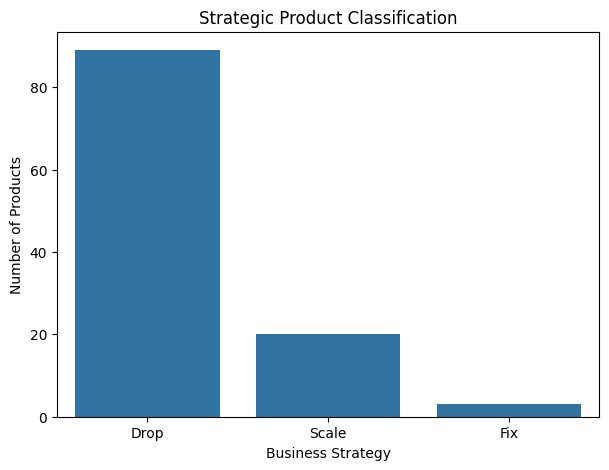

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='strategy_action',
    data=nike_reviews_df
)

plt.title("Strategic Product Classification")

plt.xlabel("Business Strategy")

plt.ylabel("Number of Products")

plt.show()

In [43]:
# ============================================
# TOP PRODUCTS TO SCALE
# ============================================

scale_products = nike_reviews_df[
    nike_reviews_df['strategy_action'] == 'Scale'
]

top_scale = scale_products.sort_values(
    by='success_score',
    ascending=False
).head(10)

print(
    top_scale[['name', 'success_score']]
)

                                       name  success_score
53                           Nike Essential       3.590000
6    Kristaps Porziņģis Knicks Icon Edition       3.502848
106                         Nike Sportswear       3.502848
1                              Club América       3.500949
56                            Nike 8-Pound        3.500949
8                           Nike Sportswear       3.500949
51                                     Nike       3.500949
20     Denver Nuggets Nike x Filip Pagowski       3.500949
35                             Nike Dri-FIT       3.500949
97                            Nike ACG AW84       3.500949


In [44]:
# ============================================
# PRODUCTS TO FIX
# ============================================

fix_products = nike_reviews_df[
    nike_reviews_df['strategy_action'] == 'Fix'
]

print(
    fix_products[['name', 'avg_rating']]
    .head(10)
)

                  name  avg_rating
28         Nike Myriad         5.0
49   Nike SFB Gen 2 8”         3.8
104               Nike         3.9


In [45]:
# ============================================
# PRODUCTS TO DROP
# ============================================

drop_products = nike_reviews_df[
    nike_reviews_df['strategy_action'] == 'Drop'
]

print(
    drop_products[['name', 'avg_rating']]
    .head(10)
)

                                              name  avg_rating
0          Nike Dri-FIT Team (MLB Minnesota Twins)         NaN
3                            Nike Dri-FIT One Luxe         NaN
4            Paris Saint-Germain Repel Academy AWF         NaN
5                NFL Miami Dolphins (Mike Gesicki)         NaN
7                            Nike College (Oregon)         NaN
9   Nike Therma Crucial Catch (NFL Miami Dolphins)         NaN
10                     Nike Sportswear Tech Fleece         NaN
11                      Paris Saint-Germain Strike         NaN
12                    Croatia 2022/23 Stadium Away         NaN
13     Nike Therma Lockup (NFL Kansas City Chiefs)         NaN


# 23. Executive Summary Table

In [46]:
# ============================================
# EXECUTIVE KPI SUMMARY
# ============================================

total_products = nike_reviews_df.shape[0]

average_price = nike_reviews_df['price'].mean()

average_rating = nike_reviews_df['avg_rating'].mean()

average_sentiment = nike_reviews_df['sentiment_score'].mean()

total_reviews = nike_reviews_df['review_count'].sum()

print("Total Products:", total_products)

print("Average Price:", round(average_price,2))

print("Average Rating:", round(average_rating,2))

print("Average Sentiment Score:", round(average_sentiment,2))

print("Total Reviews:", total_reviews)

Total Products: 112
Average Price: 61.51
Average Rating: 4.77
Average Sentiment Score: 0.2
Total Reviews: 722.0


In [47]:
# ============================================
# EXECUTIVE SUMMARY TABLE
# ============================================

summary = pd.DataFrame({

    'Metric': [
        'Average Rating',
        'Average Price',
        'Average Sentiment',
        'Total Reviews'
    ],

    'Value': [
        round(average_rating,2),
        round(average_price,2),
        round(average_sentiment,2),
        total_reviews
    ]
})

print(summary)

              Metric   Value
0     Average Rating    4.77
1      Average Price   61.51
2  Average Sentiment    0.20
3      Total Reviews  722.00


# 24. Strategic Recommendations

In [48]:
# ============================================
# STRATEGIC RECOMMENDATIONS
# ============================================

print("="*60)
print("STRATEGIC RECOMMENDATIONS")
print("="*60)

print("\n1. SCALE products with avg_rating >= 4 and positive sentiment.")
print("   These are your best performers — invest in marketing and inventory.\n")

print("2. FIX products with avg_rating between 3-4.")
print("   Improve product quality, descriptions, or pricing strategy.\n")

print("3. DROP products with avg_rating < 3.")
print("   These underperform and may harm overall brand perception.\n")

print("4. Focus on high-engagement, lower-priced products")
print("   for volume-driven revenue growth.\n")

print("5. Use sentiment insights to improve product descriptions")
print("   and respond to negative feedback proactively.")

STRATEGIC RECOMMENDATIONS

1. SCALE products with avg_rating >= 4 and positive sentiment.
   These are your best performers — invest in marketing and inventory.

2. FIX products with avg_rating between 3-4.
   Improve product quality, descriptions, or pricing strategy.

3. DROP products with avg_rating < 3.
   These underperform and may harm overall brand perception.

4. Focus on high-engagement, lower-priced products
   for volume-driven revenue growth.

5. Use sentiment insights to improve product descriptions
   and respond to negative feedback proactively.


# 25. Conclusion

In [49]:
# ============================================
# CONCLUSION
# ============================================

print("="*60)
print("CONCLUSION")
print("="*60)

print(f"""
This analysis of the Nike/Adidas sportswear market reveals:

- Total Products Analyzed : {total_products}
- Average Product Rating  : {round(average_rating, 2)}
- Average Price           : {round(average_price, 2)}
- Average Sentiment Score : {round(average_sentiment, 2)}
- Total Customer Reviews  : {total_reviews}

Key findings:
  * Most products carry positive sentiment, indicating general
    customer satisfaction.
  * Price does not strongly correlate with higher ratings,
    suggesting quality and fit matter more than brand premium.
  * A clear segmentation into Scale / Fix / Drop categories
    enables data-driven portfolio decisions.

This project demonstrates how NLP, statistical analysis, and
business strategy frameworks can be combined to generate
actionable insights from e-commerce data.
""")

CONCLUSION

This analysis of the Nike/Adidas sportswear market reveals:

- Total Products Analyzed : 112
- Average Product Rating  : 4.77
- Average Price           : 61.51
- Average Sentiment Score : 0.2
- Total Customer Reviews  : 722.0

Key findings:
  * Most products carry positive sentiment, indicating general
    customer satisfaction.
  * Price does not strongly correlate with higher ratings,
    suggesting quality and fit matter more than brand premium.
  * A clear segmentation into Scale / Fix / Drop categories
    enables data-driven portfolio decisions.

This project demonstrates how NLP, statistical analysis, and
business strategy frameworks can be combined to generate
actionable insights from e-commerce data.



# 26. Limitation

In [50]:
# ============================================
# LIMITATIONS
# ============================================

print("="*60)
print("LIMITATIONS")
print("="*60)

limitations = [
    "1. Dataset Scope: Analysis is limited to two brands (Nike & Adidas).",
    "   Results may not generalise to the broader sportswear market.",
    "",
    "2. Sentiment Analysis: TextBlob uses a simple lexicon-based approach.",
    "   It may miss sarcasm, slang, or domain-specific language.",
    "",
    "3. Static Dataset: The dataset is a snapshot in time.",
    "   Prices, ratings, and reviews change continuously.",
    "",
    "4. Missing Features: Variables such as product category, season,",
    "   geography, and return rates are not included.",
    "",
    "5. Review Bias: Products with very few reviews may skew ratings.",
    "   No minimum review threshold was applied.",
    "",
    "6. Currency / Normalisation: Prices are not normalised for region,",
    "   which may distort cross-brand price comparisons.",
]

for line in limitations:
    print(line)

LIMITATIONS
1. Dataset Scope: Analysis is limited to two brands (Nike & Adidas).
   Results may not generalise to the broader sportswear market.

2. Sentiment Analysis: TextBlob uses a simple lexicon-based approach.
   It may miss sarcasm, slang, or domain-specific language.

3. Static Dataset: The dataset is a snapshot in time.
   Prices, ratings, and reviews change continuously.

4. Missing Features: Variables such as product category, season,
   geography, and return rates are not included.

5. Review Bias: Products with very few reviews may skew ratings.
   No minimum review threshold was applied.

6. Currency / Normalisation: Prices are not normalised for region,
   which may distort cross-brand price comparisons.
